# EDA — Traffic Crashes Resulting in Injury

Notebook exploratorio para el dataset `Traffic_Crashes_Resulting_in_Injury_20260527.csv`.

In [1]:
# Librerías principales
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## 1. Carga del dataset

In [2]:
DATA_FILE = "accidentes-injury-histo.csv"

data_path = Path(DATA_FILE)
if not data_path.exists():
    data_path = Path("../") / DATA_FILE

assert data_path.exists(), f"No se encontró el archivo: {data_path}"

df_raw = pd.read_csv(data_path, low_memory=False)
df = df_raw.copy()

print(f"Archivo: {data_path}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
display(df.head())

Archivo: ..\accidentes-injury-histo.csv
Filas: 64,694
Columnas: 58


,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,case_id_pkey,tb_latitude,tb_longitude,geocode_source,geocode_location,collision_datetime,collision_date,collision_time,accident_year,month,day_of_week,time_cat,juris,officer_id,reporting_district,beat_number,primary_rd,secondary_rd,distance,direction,weather_1,weather_2,collision_severity,type_of_collision,mviw,ped_action,road_surface,road_cond_1,road_cond_2,lighting,control_device,intersection,vz_pcf_code,vz_pcf_group,vz_pcf_description,vz_pcf_link,number_killed,number_injured,street_view,dph_col_grp,dph_col_grp_description,party_at_fault,party1_type,party1_dir_of_travel,party1_move_pre_acc,party2_type,party2_dir_of_travel,party2_move_pre_acc,point,data_as_of,data_updated_at,data_loaded_at,analysis_neighborhood,supervisor_district,police_district
0,50327,"26,037,000.000",NaN,190826792,"37,7749028314","-122,431011539",SFPD-INTERIM DB,CITY STREET,2019 Nov 01 12:57:00 PM,2019 November 01,12:57:00,2019,November,Friday,10:01 am to 2:00 pm,3801,964,Northern,3E1A,FELL ST,FILLMORE ST,0.000,Not Stated,Clear,Not Stated,Injury (Other Visible),Other,Non-Collision,No Pedestrian Involved,Dry,No Unusual Condition,Not Stated,Daylight,Functioning,Intersection <= 20ft,Unknown,Unknown,Unknown,NaN,0.000,1,https://maps.google.com/maps?q=&layer=c&cbll=3...,AA,Vehicle(s) Only Involved,NaN,Driver,West,Proceeding Straight,NaN,NaN,NaN,POINT (-122.431011539 37.774902831),2019 Nov 13 12:00:00 AM,2025 Apr 28 12:00:00 AM,2026 May 01 12:27:24 PM,Hayes Valley,5.000,NORTHERN
1,127581,"30,731,000.000",NaN,240768967,"37,79101664852","-122,39914859836",SFPD-INTERIM DB,CITY STREET,2024 Nov 06 02:38:00 PM,2024 November 06,14:38:00,2024,November,Wednesday,2:01 pm to 6:00 pm,3801,1190,Southern,1,MARKET ST,01ST ST,0.000,Not Stated,Clear,Not Stated,Injury (Other Visible),Overturned,Non-Collision,No Pedestrian Involved,Dry,Other,Not Stated,Daylight,NaN,Intersection <= 20ft,NaN,NaN,Unknown,NaN,0.000,1,https://maps.google.com/maps?q=&layer=c&cbll=3...,FF,Bicycle Only,NaN,Bicyclist,East,Proceeding Straight,NaN,NaN,NaN,POINT (-122.399148598 37.791016649),2026 Mar 20 12:00:00 AM,2026 Mar 20 12:00:00 AM,2026 May 01 12:27:24 PM,Financial District/South Beach,6.000,SOUTHERN
2,126576,"25,186,000.000",NaN,250101272,"37,78289412149","-122,42081700327",SFPD-INTERIM DB,CITY STREET,2025 Feb 13 06:45:00 AM,2025 February 13,06:45:00,2025,February,Thursday,6:01 am to 10:00 am,3801,964,Northern,3E13D,EDDY ST,VAN NESS AVE,0.000,Not Stated,Other,Not Stated,Injury (Other Visible),Other,Pedestrian,Crossing in Crosswalk at Intersection,Not Stated,Not Stated,Not Stated,Not Stated,Not Stated,Intersection <= 20ft,NaN,NaN,Unknown,NaN,0.000,1,https://maps.google.com/maps?q=&layer=c&cbll=3...,BB,Vehicle-Pedestrian,NaN,Driver,South,Other,Pedestrian,West,Proceeding Straight,POINT (-122.420817003 37.782894121),2026 Mar 20 12:00:00 AM,2026 Mar 20 12:00:00 AM,2026 May 01 12:27:24 PM,Tenderloin,5.000,NORTHERN
3,17417,"24,378,000.000","588,000.000",5130580,"37,76816476098","-122,4217840978",SFPD-CROSSROADS,CITY STREET,2011 Mar 27 12:45:00 PM,2011 March 27,12:45:00,2011,March,Sunday,10:01 am to 2:00 pm,3801,191,MISSI,4B2D,14TH ST,VALENCIA ST,120.000,East,Clear,Not Stated,Injury (Complaint of Pain),Hit Object,Bicycle,No Pedestrian Involved,Dry,No Unusual Condition,Not Stated,Daylight,Functioning,Midblock > 20ft,22517,22517,Opening door on traffic side when unsafe,http://leginfo.legislature.ca.gov/faces/codes_...,0.000,1,https://maps.google.com/maps?q=&layer=c&cbll=3...,CC,Vehicle-Bicycle,1.000,Other,East,Parked,Bicyclist,East,Proceeding Straight,POINT (-122.421784098 37.768164761),2011 Mar 27 12:00:00 AM,2023 Apr 26 12:00:00 AM,2026 May 01 12:27:24 PM,Mission,9.000,MISSION
4,18653,"30,749,000.000","8,756,101.000",4279173,"37,77420983116","-122,42036142057",SFPD-CROSSROADS,CITY STREET,2009 Jun 18 10:10:00 AM,2009 June 18,10:10:00,2009,June,Thursday,10:01 am to 2:00 pm,3801,2348,NaN,03B,MARKET ST,12TH ST,60.000,West,Clear,Not Stated,Injury (Other Visible),Other,Non

## 2. Funciones auxiliares

In [3]:
def missingness_table(data: pd.DataFrame) -> pd.DataFrame:
    """Tabla de nulos ordenada por porcentaje descendente."""
    miss = data.isna().sum()
    out = (
        pd.DataFrame({
            "missing_count": miss,
            "missing_pct": miss / len(data) * 100,
            "dtype": data.dtypes.astype(str),
            "n_unique": data.nunique(dropna=True)
        })
        .sort_values(["missing_pct", "missing_count"], ascending=False)
    )
    return out


def cardinality_table(data: pd.DataFrame) -> pd.DataFrame:
    """Cardinalidad de variables categóricas / object."""
    obj_cols = data.select_dtypes(include=["object", "category", "bool"]).columns
    out = []
    for col in obj_cols:
        vc = data[col].value_counts(dropna=False)
        out.append({
            "column": col,
            "dtype": str(data[col].dtype),
            "n_unique": data[col].nunique(dropna=True),
            "top_value": vc.index[0] if len(vc) else np.nan,
            "top_count": vc.iloc[0] if len(vc) else np.nan,
            "top_pct": vc.iloc[0] / len(data) * 100 if len(vc) else np.nan
        })
    return pd.DataFrame(out).sort_values("n_unique", ascending=False)


def numeric_summary(data: pd.DataFrame) -> pd.DataFrame:
    """Resumen estadístico ampliado para columnas numéricas."""
    num = data.select_dtypes(include=[np.number])
    if num.empty:
        return pd.DataFrame()
    return num.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T


def top_categories(data: pd.DataFrame, columns, n=10) -> dict:
    """Devuelve las categorías más frecuentes para una lista de columnas."""
    result = {}
    for col in columns:
        if col in data.columns:
            result[col] = data[col].value_counts(dropna=False).head(n).to_frame("count")
            result[col]["pct"] = result[col]["count"] / len(data) * 100
    return result


def plot_counts(series: pd.Series, title: str, top_n: int = 15, xlabel: str = "Recuento"):
    """Bar chart horizontal de frecuencias."""
    counts = series.value_counts(dropna=False).head(top_n).sort_values()
    ax = counts.plot(kind="barh", figsize=(10, max(4, 0.35 * len(counts))))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


def plot_time_counts(series: pd.Series, title: str, xlabel: str = ""):
    counts = series.value_counts().sort_index()
    ax = counts.plot(kind="line", marker="o")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Recuento")
    plt.tight_layout()
    plt.show()

## 3. Estructura, tipos de datos y duplicados

In [4]:
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "null_count": df.isna().sum().values,
    "n_unique": df.nunique(dropna=True).values
}))

print("Filas duplicadas completas:", df.duplicated().sum())
if "unique_id" in df.columns:
    print("unique_id duplicados:", df["unique_id"].duplicated().sum())
if "case_id_pkey" in df.columns:
    print("case_id_pkey duplicados:", df["case_id_pkey"].duplicated().sum())

,column,dtype,non_null,null_count,n_unique
0,unique_id,int64,64694,0,64694
1,cnn_intrsctn_fkey,float64,64657,37,6200
2,cnn_sgmt_fkey,float64,28914,35780,7547
3,case_id_pkey,str,64694,0,64691
4,tb_latitude,str,64513,181,36870
5,tb_longitude,str,64513,181,36408
6,geocode_source,str,64694,0,3
7,geocode_location,str,64694,0,1
8,collision_datetime,str,64694,0,64151
9,collision_date,str,64694,0,7721


Filas duplicadas completas: 0
unique_id duplicados: 0
case_id_pkey duplicados: 3


## 4. Nulos y cardinalidad

In [5]:
miss = missingness_table(df)
display(miss)

card = cardinality_table(df)
display(card)

,missing_count,missing_pct,dtype,n_unique
cnn_sgmt_fkey,35780,55.307,float64,7547
control_device,21864,33.796,str,4
reporting_district,6510,10.063,str,885
party_at_fault,6397,9.888,float64,5
beat_number,4865,7.520,str,3582
party2_type,4703,7.270,str,6
party2_dir_of_travel,4701,7.267,str,5
party2_move_pre_acc,4700,7.265,str,21
officer_id,1103,1.705,str,4080
vz_pcf_link,1082,1.672,str,210


C:\Users\Samuel\AppData\Local\Temp\ipykernel_15768\3936774470.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = data.select_dtypes(include=["object", "category", "bool"]).columns


,column,dtype,n_unique,top_value,top_count,top_pct
0,case_id_pkey,str,64691,250210055,2,0.003
5,collision_datetime,str,64151,2010 Feb 15 06:50:00 PM,4,0.006
34,street_view,str,39613,NaN,126,0.195
1,tb_latitude,str,36870,NaN,181,0.280
2,tb_longitude,str,36408,NaN,181,0.280
43,point,str,34854,NaN,181,0.280
6,collision_date,str,7721,2016 December 08,23,0.036
44,data_as_of,str,5143,2026 Mar 20 12:00:00 AM,9059,14.003
12,officer_id,str,4080,NaN,1103,1.705
14,beat_number,str,3582,NaN,4865,7.520


## 5. Limpieza ligera y variables derivadas

In [6]:
# Coordenadas: vienen como strings con coma decimal en varias filas.
def parse_decimal_comma(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce"
    )

if "tb_latitude" in df.columns:
    df["latitude"] = parse_decimal_comma(df["tb_latitude"])
if "tb_longitude" in df.columns:
    df["longitude"] = parse_decimal_comma(df["tb_longitude"])

# Fechas principales
date_cols = ["collision_datetime", "collision_date", "data_as_of", "data_updated_at", "data_loaded_at"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Tiempos: se extrae hora cuando es posible.
if "collision_time" in df.columns:
    parsed_time = pd.to_datetime(df["collision_time"], errors="coerce")
    df["collision_hour_from_time"] = parsed_time.dt.hour

if "collision_datetime" in df.columns:
    df["collision_year_parsed"] = df["collision_datetime"].dt.year
    df["collision_month_num"] = df["collision_datetime"].dt.month
    df["collision_month_name"] = df["collision_datetime"].dt.month_name()
    df["collision_dayofweek"] = df["collision_datetime"].dt.day_name()
    df["collision_hour"] = df["collision_datetime"].dt.hour

# Numéricos relevantes
for col in ["number_killed", "number_injured", "distance", "supervisor_district"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

display(df.head())

,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,case_id_pkey,tb_latitude,tb_longitude,geocode_source,geocode_location,collision_datetime,collision_date,collision_time,accident_year,month,day_of_week,time_cat,juris,officer_id,reporting_district,beat_number,primary_rd,secondary_rd,distance,direction,weather_1,weather_2,collision_severity,type_of_collision,mviw,ped_action,road_surface,road_cond_1,road_cond_2,lighting,control_device,intersection,vz_pcf_code,vz_pcf_group,vz_pcf_description,vz_pcf_link,number_killed,number_injured,street_view,dph_col_grp,dph_col_grp_description,party_at_fault,party1_type,party1_dir_of_travel,party1_move_pre_acc,party2_type,party2_dir_of_travel,party2_move_pre_acc,point,data_as_of,data_updated_at,data_loaded_at,analysis_neighborhood,supervisor_district,police_district,latitude,longitude,collision_hour_from_time,collision_year_parsed,collision_month_num,collision_month_name,collision_dayofweek,collision_hour
0,50327,"26,037,000.000",NaN,190826792,"37,7749028314","-122,431011539",SFPD-INTERIM DB,CITY STREET,2019-11-01 12:57:00,2019-11-01,12:57:00,2019,November,Friday,10:01 am to 2:00 pm,3801,964,Northern,3E1A,FELL ST,FILLMORE ST,0.000,Not Stated,Clear,Not Stated,Injury (Other Visible),Other,Non-Collision,No Pedestrian Involved,Dry,No Unusual Condition,Not Stated,Daylight,Functioning,Intersection <= 20ft,Unknown,Unknown,Unknown,NaN,0.000,1,https://maps.google.com/maps?q=&layer=c&cbll=3...,AA,Vehicle(s) Only Involved,NaN,Driver,West,Proceeding Straight,NaN,NaN,NaN,POINT (-122.431011539 37.774902831),2019-11-13,2025-04-28,2026-05-01 12:27:24,Hayes Valley,5.000,NORTHERN,37.775,-122.431,12.000,2019,11,November,Friday,12
1,127581,"30,731,000.000",NaN,240768967,"37,79101664852","-122,39914859836",SFPD-INTERIM DB,CITY STREET,2024-11-06 14:38:00,2024-11-06,14:38:00,2024,November,Wednesday,2:01 pm to 6:00 pm,3801,1190,Southern,1,MARKET ST,01ST ST,0.000,Not Stated,Clear,Not Stated,Injury (Other Visible),Overturned,Non-Collision,No Pedestrian Involved,Dry,Other,Not Stated,Daylight,NaN,Intersection <= 20ft,NaN,NaN,Unknown,NaN,0.000,1,https://maps.google.com/maps?q=&layer=c&cbll=3...,FF,Bicycle Only,NaN,Bicyclist,East,Proceeding Straight,NaN,NaN,NaN,POINT (-122.399148598 37.791016649),2026-03-20,2026-03-20,2026-05-01 12:27:24,Financial District/South Beach,6.000,SOUTHERN,37.791,-122.399,14.000,2024,11,November,Wednesday,14
2,126576,"25,186,000.000",NaN,250101272,"37,78289412149","-122,42081700327",SFPD-INTERIM DB,CITY STREET,2025-02-13 06:45:00,2025-02-13,06:45:00,2025,February,Thursday,6:01 am to 10:00 am,3801,964,Northern,3E13D,EDDY ST,VAN NESS AVE,0.000,Not Stated,Other,Not Stated,Injury (Other Visible),Other,Pedestrian,Crossing in Crosswalk at Intersection,Not Stated,Not Stated,Not Stated,Not Stated,Not Stated,Intersection <= 20ft,NaN,NaN,Unknown,NaN,0.000,1,https://maps.google.com/maps?q=&layer=c&cbll=3...,BB,Vehicle-Pedestrian,NaN,Driver,South,Other,Pedestrian,West,Proceeding Straight,POINT (-122.420817003 37.782894121),2026-03-20,2026-03-20,2026-05-01 12:27:24,Tenderloin,5.000,NORTHERN,37.783,-122.421,6.000,2025,2,February,Thursday,6
3,17417,"24,378,000.000","588,000.000",5130580,"37,76816476098","-122,4217840978",SFPD-CROSSROADS,CITY STREET,2011-03-27 12:45:00,2011-03-27,12:45:00,2011,March,Sunday,10:01 am to 2:00 pm,3801,191,MISSI,4B2D,14TH ST,VALENCIA ST,120.000,East,Clear,Not Stated,Injury (Complaint of Pain),Hit Object,Bicycle,No Pedestrian Involved,Dry,No Unusual Condition,Not Stated,Daylight,Functioning,Midblock > 20ft,22517,22517,Opening door on traffic side when unsafe,http://leginfo.legislature.ca.gov/faces/codes_...,0.000,1,https://maps.google.com/maps?q=&layer=c&cbll=3...,CC,Vehicle-Bicycle,1.000,Other,East,Parked,Bicyclist,East,Proceeding Straight,POINT (-122.421784098 37.768164761),2011-03-27,2023-04-26,2026-05-01 12:27:24,Mission,9.000,MISSION,37.768,-122.422,12.000,2011,3,March,Sunday,12
4,18653,"30,749,000.000","8,756,101.000",4279173,"37,77420983116","-122,42036142057",SFPD-CROSSROADS,CITY STREET

## 6. Resumen estadístico

In [7]:
display(numeric_summary(df))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
unique_id,"64,694.000","45,232.500","39,637.777",1.000,672.930,"3,378.650","16,888.250","33,683.500","53,842.750","130,254.350","132,842.070","133,731.000"
cnn_intrsctn_fkey,"64,657.000","25,858,798.259","4,956,300.550","20,006,000.000","20,219,000.000","20,737,000.000","23,855,000.000","24,932,000.000","26,690,000.000","33,430,000.000","52,247,440.000","54,372,000.000"
cnn_sgmt_fkey,"28,914.000","6,982,166.368","4,078,698.253","100,000.000","184,014.000","374,001.000","3,452,000.000","7,298,000.000","10,172,000.000","13,060,000.000","13,774,740.000","19,999,101.000"
accident_year,"64,694.000","2,014.995",6.051,"2,005.000","2,005.000","2,005.000","2,010.000","2,015.000","2,020.000","2,025.000","2,025.000","2,026.000"
distance,"64,615.000",45.990,96.364,0.000,0.000,0.000,0.000,0.000,50.000,226.000,471.000,997.000
number_killed,"64,691.000",0.010,0.101,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.000
number_injured,"64,694.000",1.252,0.700,0.000,0.000,1.000,1.000,1.000,1.000,3.000,4.000,19.000
party_at_fault,"58,297.000",1.013,0.125,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,5.000
supervisor_district,"64,432.000",6.087,2.910,1.000,1.000,1.000,4.000,6.000,9.000,11.000,11.000,11.000
latitude,"64,513.000",37.766,0.024,37.704,37.710,37.718,37.749,37.773,37.784,37.799,37.806,37.830


## 7. Severidad y número de lesionados

,count,pct
collision_severity,,
Injury (Complaint of Pain),41129,63.575
Injury (Other Visible),18388,28.423
Injury (Severe),4561,7.050
Fatal,615,0.951
Medical,1,0.002


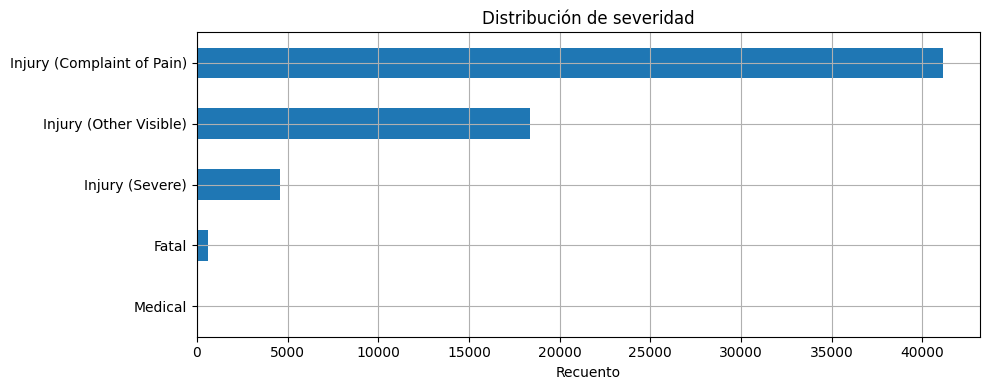

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
number_injured,"64,694.000",1.252,0.700,0.000,0.000,1.000,1.000,1.000,1.000,3.000,4.000,19.000


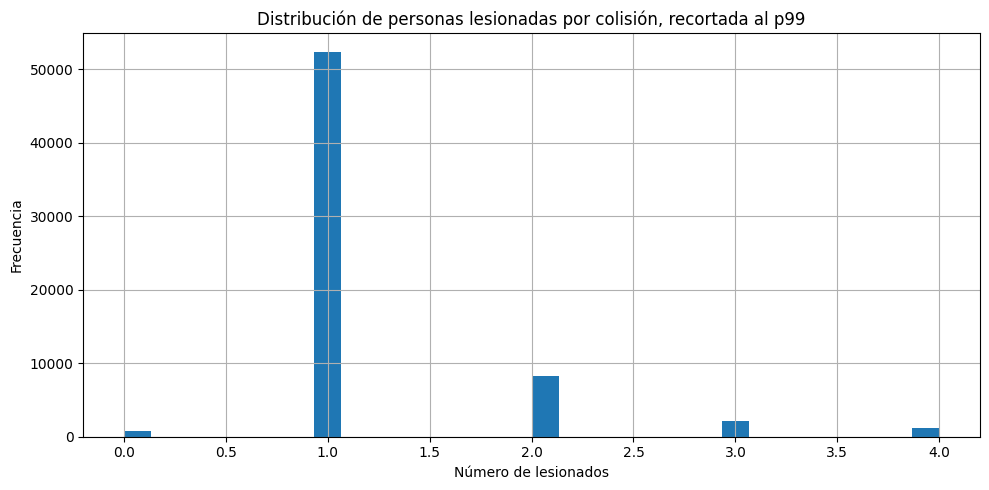

,count,pct
number_killed,,
0.000,64072,99.039
1.000,607,0.938
2.000,10,0.015
3.000,1,0.002
4.000,1,0.002
NaN,3,0.005


In [8]:
if "collision_severity" in df.columns:
    severity = df["collision_severity"].value_counts(dropna=False).to_frame("count")
    severity["pct"] = severity["count"] / len(df) * 100
    display(severity)
    plot_counts(df["collision_severity"], "Distribución de severidad", top_n=10)

if "number_injured" in df.columns:
    display(df["number_injured"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame().T)
    ax = df["number_injured"].dropna().clip(upper=df["number_injured"].quantile(.99)).plot(kind="hist", bins=30)
    ax.set_title("Distribución de personas lesionadas por colisión, recortada al p99")
    ax.set_xlabel("Número de lesionados")
    ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

if "number_killed" in df.columns:
    killed = df["number_killed"].value_counts(dropna=False).sort_index().to_frame("count")
    killed["pct"] = killed["count"] / len(df) * 100
    display(killed)

## 8. Patrones temporales

,injury_crashes
accident_year,
2005,3253
2006,2896
2007,3065
2008,3039
2009,2900
2010,3095
2011,3097
2012,3269
2013,3069


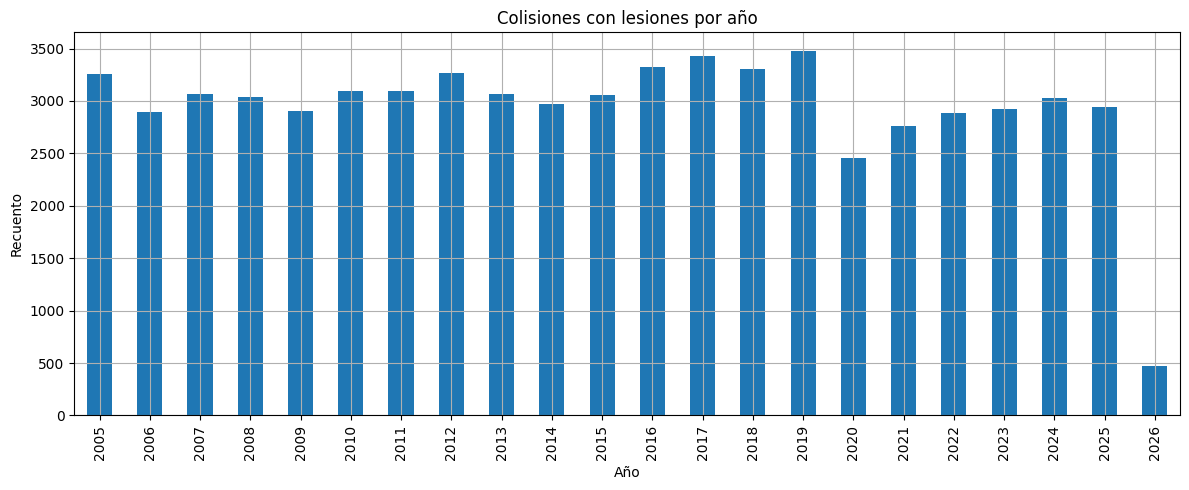

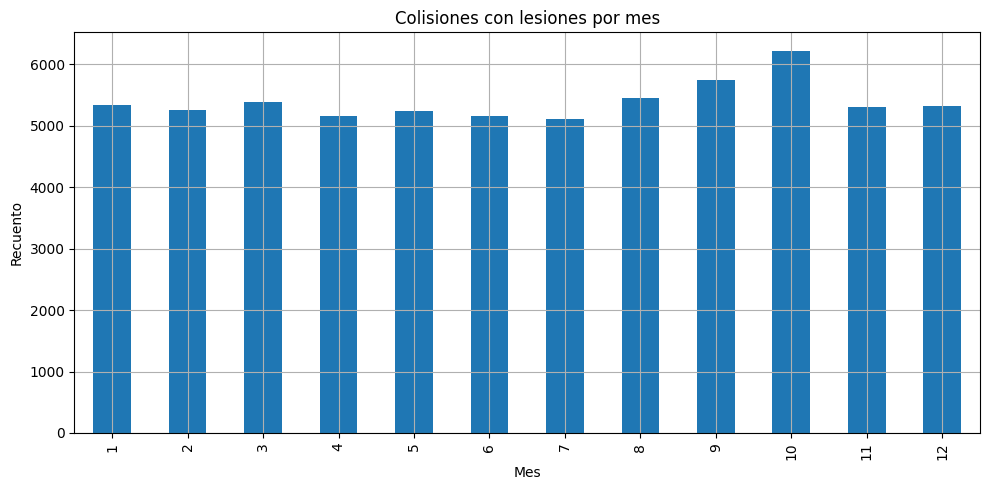

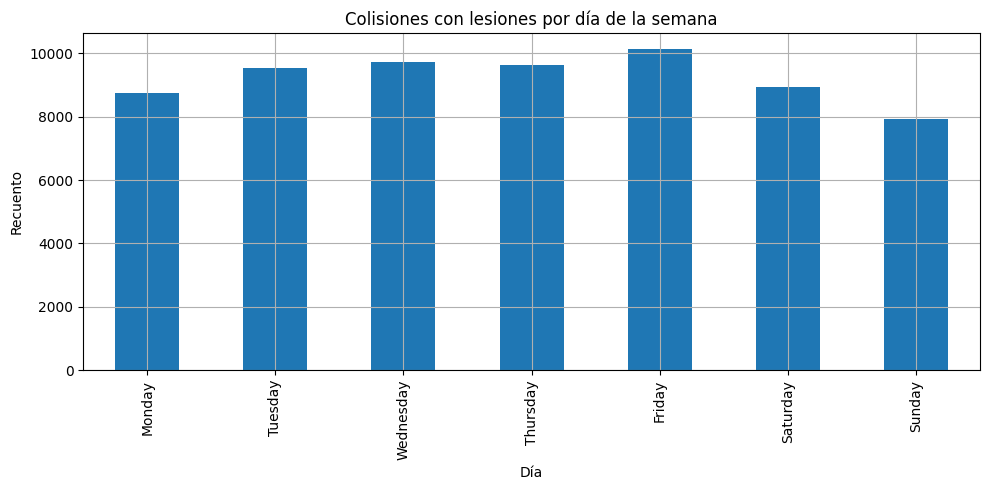

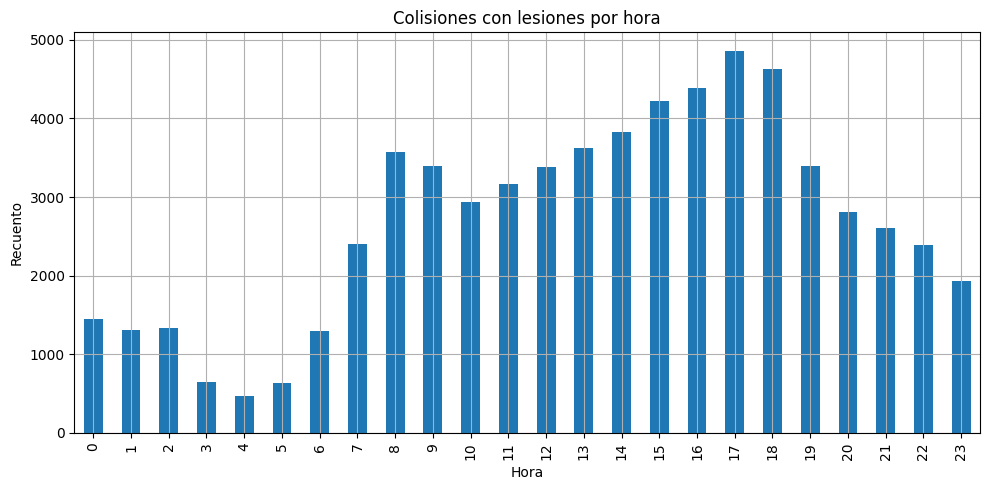

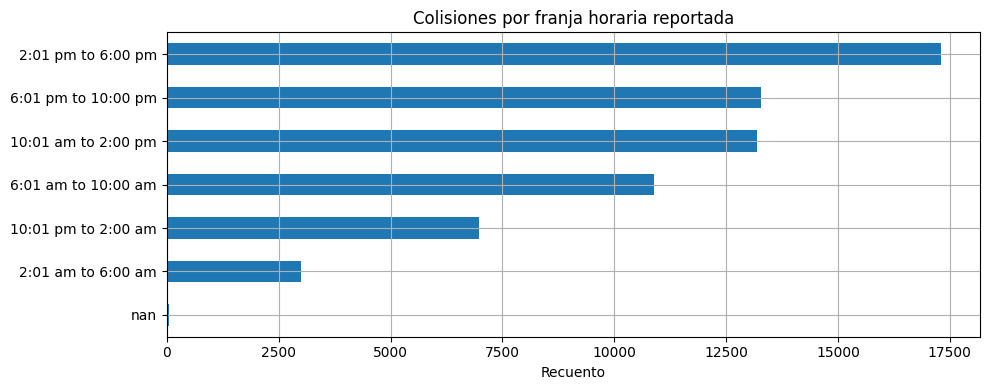

In [9]:
if "accident_year" in df.columns:
    year_counts = df["accident_year"].value_counts().sort_index()
    display(year_counts.to_frame("injury_crashes"))
    ax = year_counts.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Colisiones con lesiones por año")
    ax.set_xlabel("Año")
    ax.set_ylabel("Recuento")
    plt.tight_layout()
    plt.show()

if "collision_month_num" in df.columns:
    month_counts = df["collision_month_num"].value_counts().sort_index()
    ax = month_counts.plot(kind="bar")
    ax.set_title("Colisiones con lesiones por mes")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Recuento")
    plt.tight_layout()
    plt.show()

if "day_of_week" in df.columns:
    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    dow_counts = df["day_of_week"].value_counts().reindex(order)
    ax = dow_counts.plot(kind="bar")
    ax.set_title("Colisiones con lesiones por día de la semana")
    ax.set_xlabel("Día")
    ax.set_ylabel("Recuento")
    plt.tight_layout()
    plt.show()

if "collision_hour" in df.columns:
    hour_counts = df["collision_hour"].value_counts().sort_index()
    ax = hour_counts.plot(kind="bar")
    ax.set_title("Colisiones con lesiones por hora")
    ax.set_xlabel("Hora")
    ax.set_ylabel("Recuento")
    plt.tight_layout()
    plt.show()

if "time_cat" in df.columns:
    plot_counts(df["time_cat"], "Colisiones por franja horaria reportada", top_n=20)

## 9. Tipología de colisión y contexto vial


Top categorías — type_of_collision


,count,pct
type_of_collision,,
Broadside,19832,30.655
Vehicle/Pedestrian,13389,20.696
Rear End,10463,16.173
Sideswipe,8553,13.221
Head-On,3942,6.093
Other,3391,5.242
Hit Object,2465,3.810
Not Stated,1507,2.329
Overturned,1152,1.781



Top categorías — dph_col_grp_description


,count,pct
dph_col_grp_description,,
Vehicle(s) Only Involved,38291,59.188
Vehicle-Pedestrian,15512,23.977
Vehicle-Bicycle,8655,13.378
Bicycle Only,1188,1.836
Bicycle-Pedestrian,512,0.791
Bicycle-Parked Car,456,0.705
Pedestrian Only or Pedestrian-Parked Car,34,0.053
Unknown/Not Stated,19,0.029
Vehicle-Bicycle-Pedestrian,19,0.029



Top categorías — mviw


...

,count,pct
vz_pcf_code,,
22350,12072,18.660
21950(a),6518,10.075
21453(a),6441,9.956
22107,4530,7.002
21801(a),3819,5.903
Unknown,3813,5.894
21703,2438,3.769
22450(a),2065,3.192
22106,2047,3.164



Top categorías — vz_pcf_group


,count,pct
vz_pcf_group,,
22350,12072,18.660
"21950(a,c)",6587,10.182
"21453(a,c)",6553,10.129
22107,4530,7.002
"21801(a,b)",3975,6.144
Unknown,3830,5.920
21703,2438,3.769
22450(a),2065,3.192
22106,2047,3.164



Top categorías — vz_pcf_description


,count,pct
vz_pcf_description,,
Unsafe speed for prevailing conditions,12072,18.660
Driver or bicyclist to yield right-of-way at crosswalks,6587,10.182
Red signal - driver or bicyclist responsibilities,6553,10.129
Unknown,4582,7.083
Unsafe turn or lane change prohibited,4530,7.002
Violation of right-of-way - left turn,3975,6.144
Following too closely prohibited,2438,3.769
Failure to stop at STOP sign,2065,3.192
Unsafe starting or backing on highway,2047,3.164


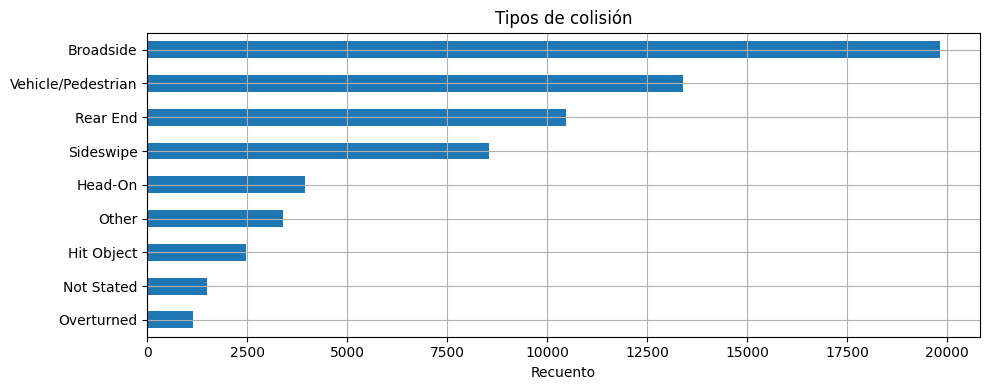

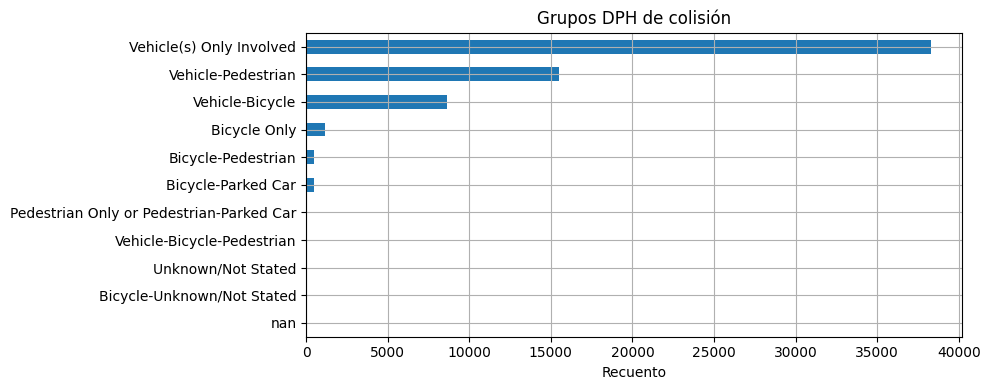

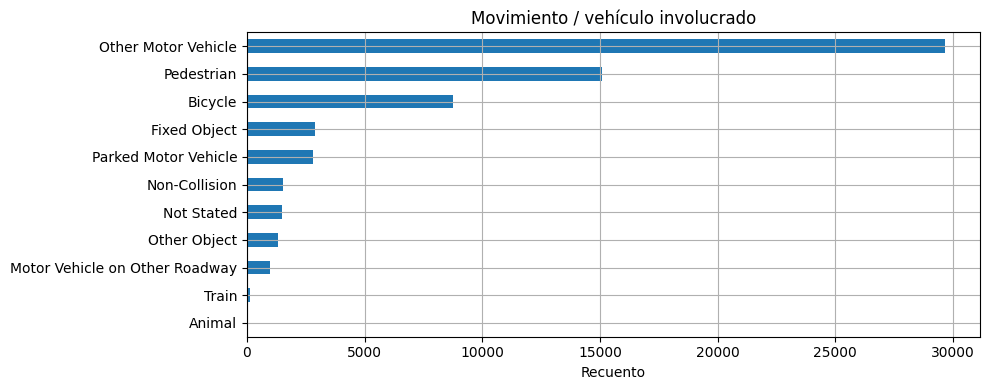

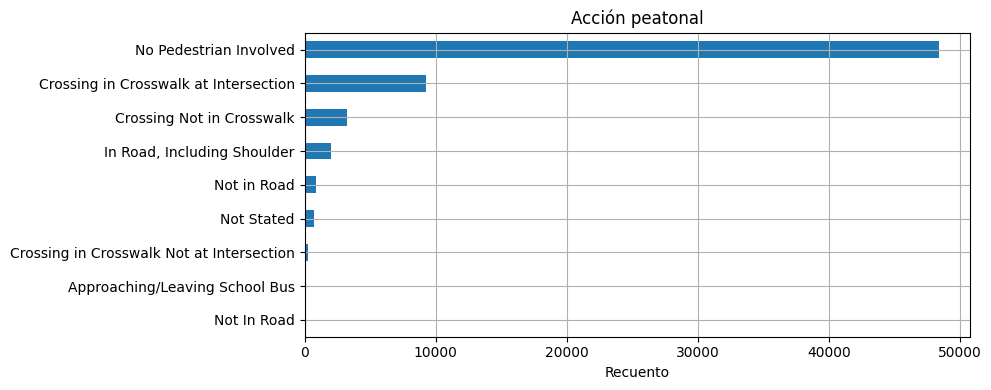

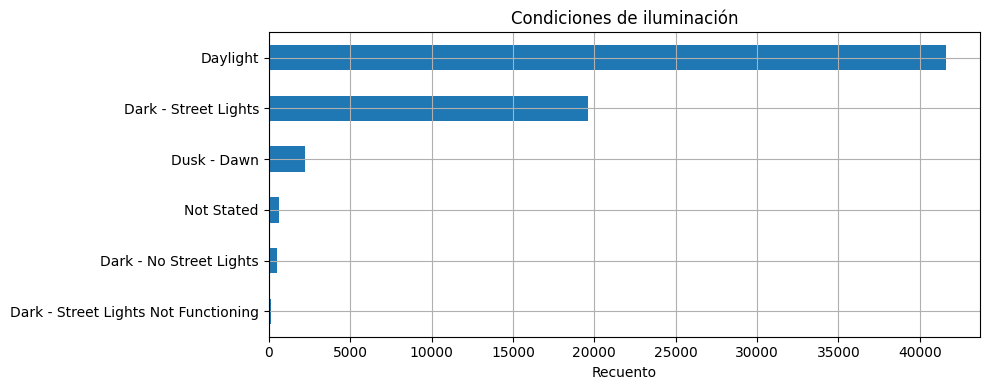

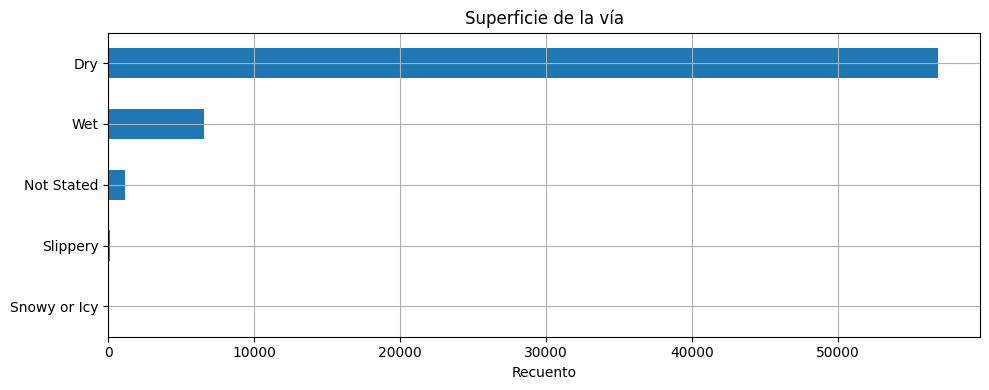

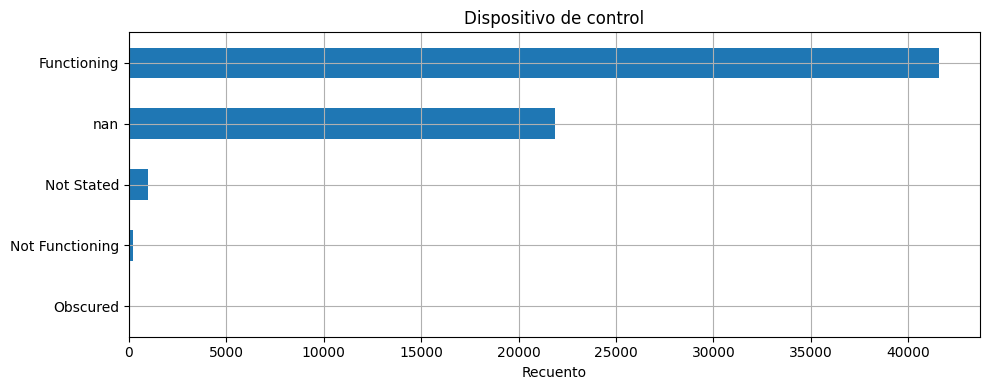

In [10]:
cols = [
    "type_of_collision", "dph_col_grp_description", "mviw", "ped_action",
    "weather_1", "weather_2", "road_surface", "road_cond_1", "road_cond_2",
    "lighting", "control_device", "intersection",
    "vz_pcf_code", "vz_pcf_group", "vz_pcf_description"
]

tops = top_categories(df, cols, n=15)
for col, table in tops.items():
    print(f"\nTop categorías — {col}")
    display(table)

for col, title in [
    ("type_of_collision", "Tipos de colisión"),
    ("dph_col_grp_description", "Grupos DPH de colisión"),
    ("mviw", "Movimiento / vehículo involucrado"),
    ("ped_action", "Acción peatonal"),
    ("lighting", "Condiciones de iluminación"),
    ("road_surface", "Superficie de la vía"),
    ("control_device", "Dispositivo de control")
]:
    if col in df.columns:
        plot_counts(df[col], title, top_n=15)

## 10. Partes involucradas


Top categorías — party_at_fault


,count,pct
party_at_fault,,
1.000,57597,89.030
NaN,6397,9.888
2.000,649,1.003
3.000,41,0.063
4.000,8,0.012
5.000,2,0.003



Top categorías — party1_type


,count,pct
party1_type,,
Driver,52826,81.655
Bicyclist,5234,8.090
Pedestrian,5022,7.763
Other,1190,1.839
Parked Vehicle,381,0.589
Not Stated,27,0.042
NaN,13,0.020
Bicycle,1,0.002



Top categorías — party1_dir_of_travel


...

,count,pct
party2_type,,
Driver,39775,61.482
Pedestrian,10692,16.527
Bicyclist,5668,8.761
NaN,4703,7.270
Parked Vehicle,2958,4.572
Other,879,1.359
Not Stated,19,0.029



Top categorías — party2_dir_of_travel


,count,pct
party2_dir_of_travel,,
East,14617,22.594
North,14398,22.256
South,14140,21.857
West,13650,21.099
NaN,4701,7.267
Not Stated,3188,4.928



Top categorías — party2_move_pre_acc


,count,pct
party2_move_pre_acc,,
Proceeding Straight,37714,58.296
Stopped In Road,5090,7.868
NaN,4700,7.265
Not Stated,3051,4.716
Making Left Turn,2825,4.367
Parked,2735,4.228
Stopped,2354,3.639
Other,1816,2.807
Making Right Turn,1564,2.418


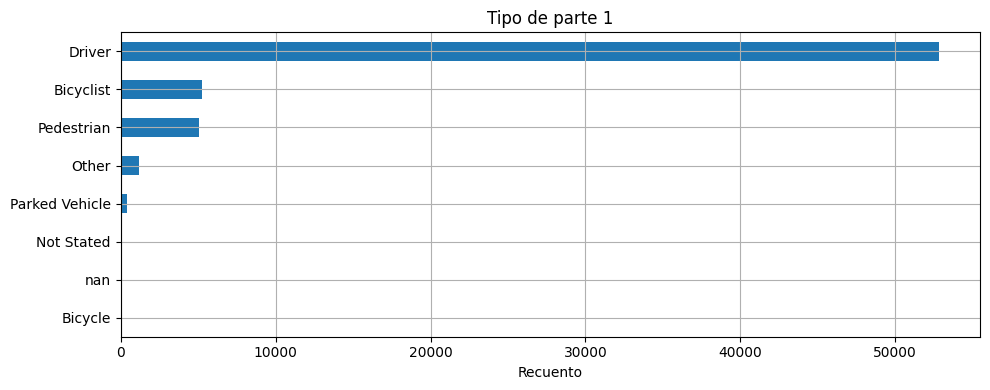

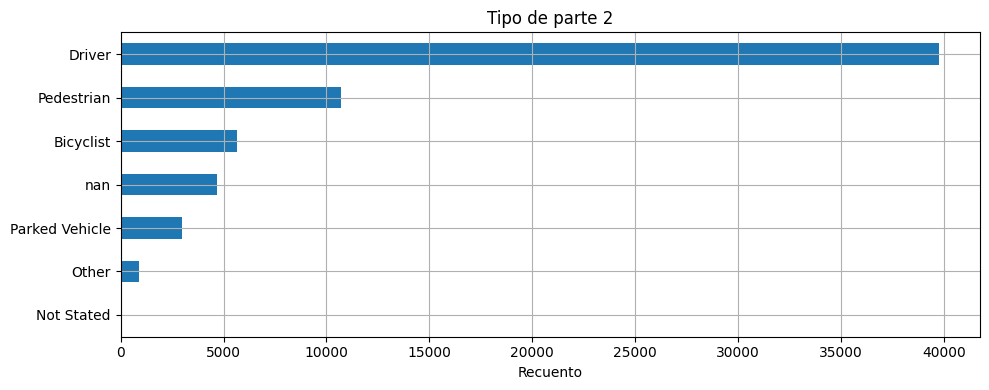

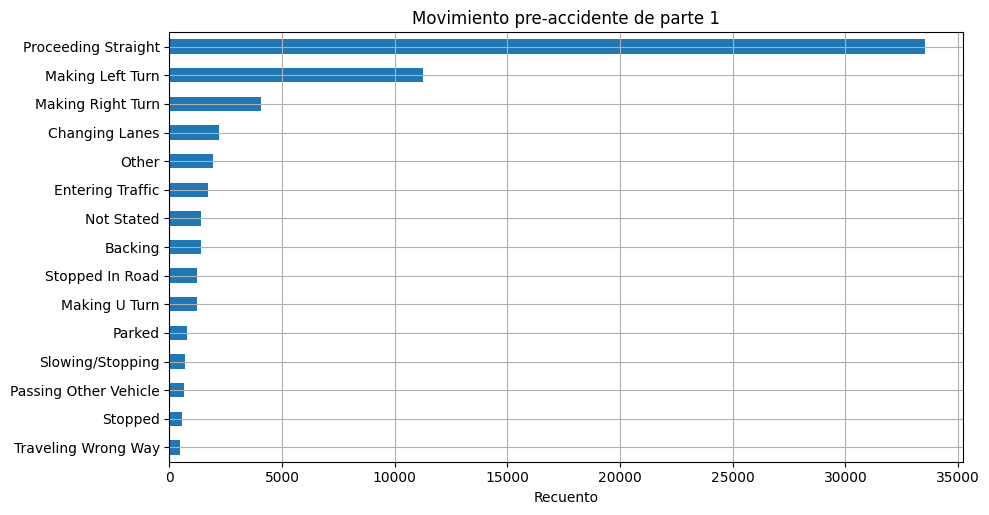

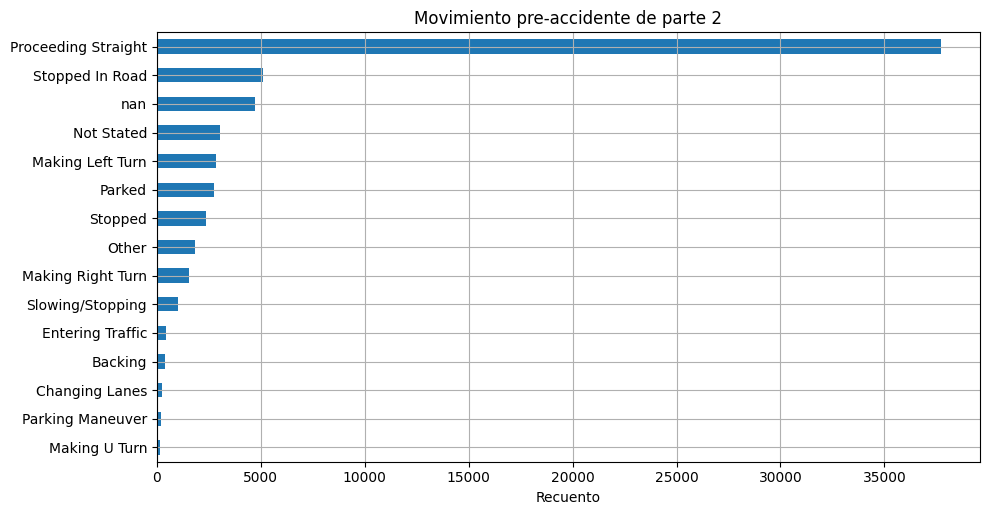

In [11]:
party_cols = [
    "party_at_fault", "party1_type", "party1_dir_of_travel", "party1_move_pre_acc",
    "party2_type", "party2_dir_of_travel", "party2_move_pre_acc"
]

tops = top_categories(df, party_cols, n=15)
for col, table in tops.items():
    print(f"\nTop categorías — {col}")
    display(table)

for col, title in [
    ("party1_type", "Tipo de parte 1"),
    ("party2_type", "Tipo de parte 2"),
    ("party1_move_pre_acc", "Movimiento pre-accidente de parte 1"),
    ("party2_move_pre_acc", "Movimiento pre-accidente de parte 2")
]:
    if col in df.columns:
        plot_counts(df[col], title, top_n=15)

## 11. Severidad cruzada con variables clave

In [12]:
def normalized_crosstab(row_col, col_col="collision_severity", min_count=0):
    if row_col not in df.columns or col_col not in df.columns:
        return pd.DataFrame()
    counts = pd.crosstab(df[row_col], df[col_col], dropna=False)
    if min_count:
        counts = counts[counts.sum(axis=1) >= min_count]
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    return counts, pct

for row_col in ["type_of_collision", "dph_col_grp_description", "party1_type", "analysis_neighborhood"]:
    if row_col in df.columns and "collision_severity" in df.columns:
        print(f"\nCruce de {row_col} por severidad — recuentos")
        counts, pct = normalized_crosstab(row_col, min_count=100)
        display(counts.sort_values(counts.columns.tolist(), ascending=False).head(20))
        print(f"Cruce de {row_col} por severidad — porcentaje por fila")
        display(pct.round(2).head(20))


Cruce de type_of_collision por severidad — recuentos


collision_severity,Fatal,Injury (Complaint of Pain),Injury (Other Visible),Injury (Severe),Medical
type_of_collision,,,,,
Vehicle/Pedestrian,312,7354,4216,1507,0
Broadside,103,13320,5289,1120,0
Hit Object,66,1189,946,264,0
Head-On,30,2296,1216,400,0
Rear End,28,8449,1684,302,0
Sideswipe,27,5574,2541,410,1
Other,23,1519,1514,335,0
Not Stated,15,941,446,105,0
Overturned,11,487,536,118,0


Cruce de type_of_collision por severidad — porcentaje por fila


collision_severity,Fatal,Injury (Complaint of Pain),Injury (Other Visible),Injury (Severe),Medical
type_of_collision,,,,,
Broadside,0.520,67.160,26.670,5.650,0.000
Head-On,0.760,58.240,30.850,10.150,0.000
Hit Object,2.680,48.240,38.380,10.710,0.000
Not Stated,1.000,62.440,29.600,6.970,0.000
Other,0.680,44.800,44.650,9.880,0.000
Overturned,0.950,42.270,46.530,10.240,0.000
Rear End,0.270,80.750,16.090,2.890,0.000
Sideswipe,0.320,65.170,29.710,4.790,0.010
Vehicle/Pedestrian,2.330,54.930,31.490,11.260,0.000



Cruce de dph_col_grp_description por severidad — recuentos


...

collision_severity,Fatal,Injury (Complaint of Pain),Injury (Other Visible),Injury (Severe),Medical
party1_type,,,,,
Bicyclist,0.690,41.100,46.640,11.560,0.020
Driver,0.810,68.150,25.320,5.730,0.000
Other,1.180,41.850,43.780,13.190,0.000
Parked Vehicle,0.260,56.170,39.370,4.200,0.000
Pedestrian,2.670,44.620,37.670,15.030,0.000



Cruce de analysis_neighborhood por severidad — recuentos


collision_severity,Fatal,Injury (Complaint of Pain),Injury (Other Visible),Injury (Severe),Medical
analysis_neighborhood,,,,,
Mission,66,5047,2408,560,0
Bayview Hunters Point,55,2702,886,307,0
South of Market,43,3312,1548,374,0
Tenderloin,40,2593,1089,305,0
Sunset/Parkside,35,1692,802,150,0
Financial District/South Beach,24,2777,1338,310,0
Western Addition,24,1734,701,166,0
Excelsior,20,1023,393,92,0
Outer Mission,19,1276,473,122,0


Cruce de analysis_neighborhood por severidad — porcentaje por fila


collision_severity,Fatal,Injury (Complaint of Pain),Injury (Other Visible),Injury (Severe),Medical
analysis_neighborhood,,,,,
Bayview Hunters Point,1.390,68.410,22.430,7.770,0.000
Bernal Heights,0.540,62.650,28.800,8.010,0.000
Castro/Upper Market,0.630,57.120,33.920,8.320,0.000
Chinatown,1.600,61.180,31.340,5.890,0.000
Excelsior,1.310,66.950,25.720,6.020,0.000
Financial District/South Beach,0.540,62.420,30.070,6.970,0.000
Glen Park,0.400,60.870,33.990,4.740,0.000
Golden Gate Park,1.030,58.090,32.740,8.140,0.000
Haight Ashbury,1.120,57.290,33.500,8.090,0.000


## 12. Análisis geográfico

,latitude,longitude,point,street_view,analysis_neighborhood,police_district,supervisor_district,primary_rd,secondary_rd
0,37.775,-122.431,POINT (-122.431011539 37.774902831),https://maps.google.com/maps?q=&layer=c&cbll=3...,Hayes Valley,NORTHERN,5.000,FELL ST,FILLMORE ST
1,37.791,-122.399,POINT (-122.399148598 37.791016649),https://maps.google.com/maps?q=&layer=c&cbll=3...,Financial District/South Beach,SOUTHERN,6.000,MARKET ST,01ST ST
2,37.783,-122.421,POINT (-122.420817003 37.782894121),https://maps.google.com/maps?q=&layer=c&cbll=3...,Tenderloin,NORTHERN,5.000,EDDY ST,VAN NESS AVE
3,37.768,-122.422,POINT (-122.421784098 37.768164761),https://maps.google.com/maps?q=&layer=c&cbll=3...,Mission,MISSION,9.000,14TH ST,VALENCIA ST
4,37.774,-122.420,POINT (-122.420361421 37.774209831),https://maps.google.com/maps?q=&layer=c&cbll=3...,Mission,SOUTHERN,6.000,MARKET ST,12TH ST


Coordenadas faltantes tras conversión:


,missing
latitude,181
longitude,181


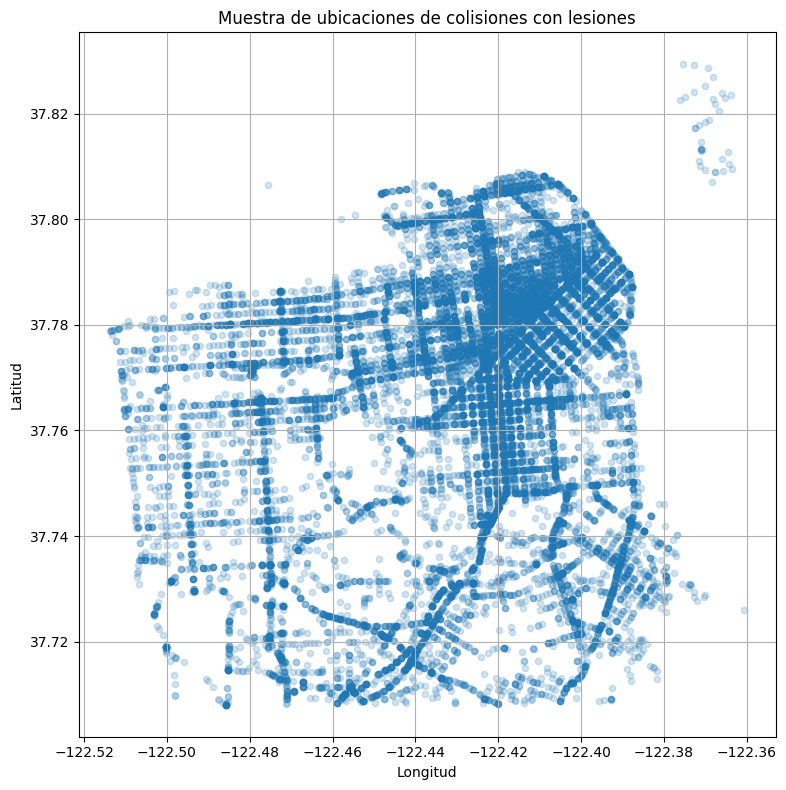

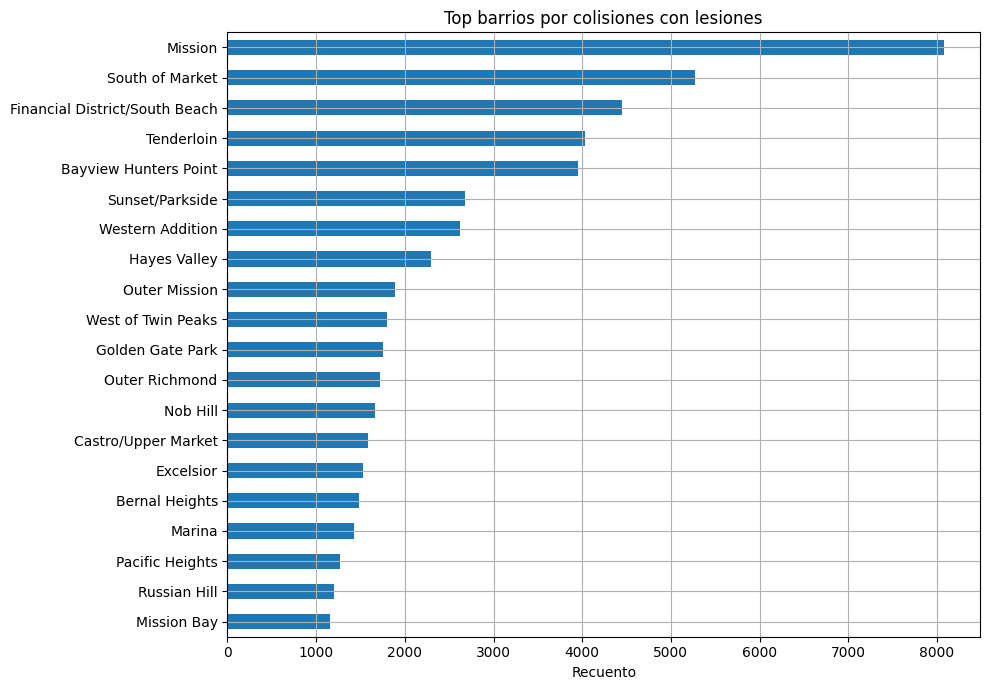

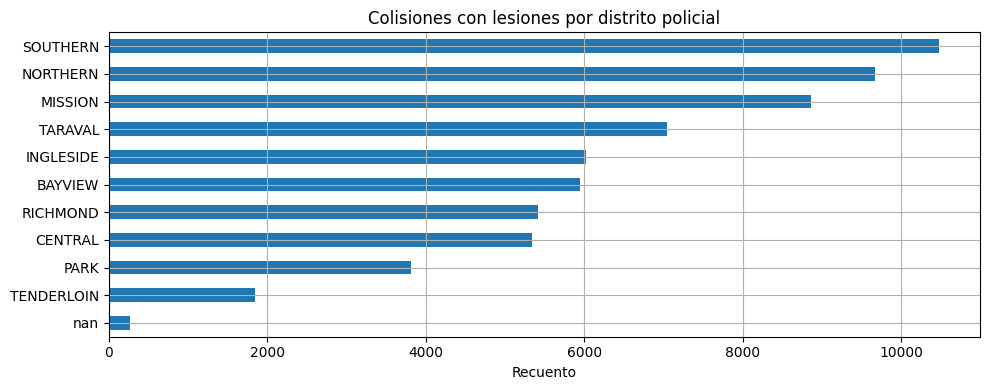

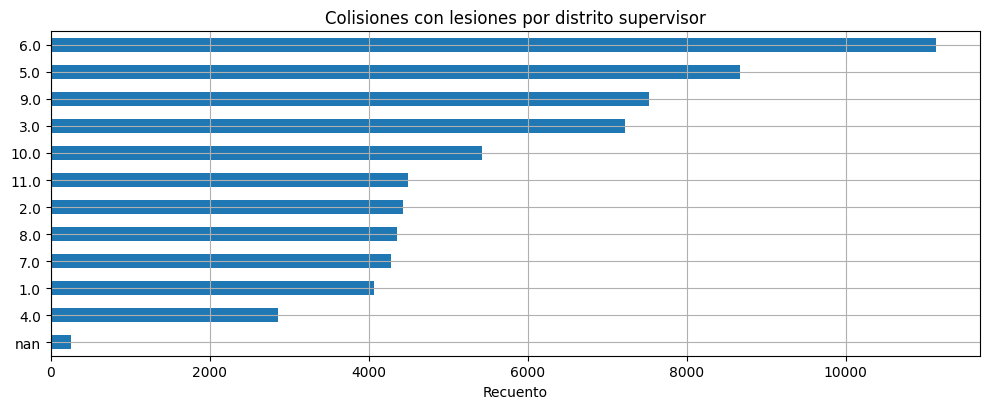

In [13]:
geo_cols = [
    "latitude", "longitude", "point", "street_view",
    "analysis_neighborhood", "police_district", "supervisor_district",
    "primary_rd", "secondary_rd"
]
display(df[[c for c in geo_cols if c in df.columns]].head())

if {"latitude", "longitude"}.issubset(df.columns):
    print("Coordenadas faltantes tras conversión:")
    display(df[["latitude", "longitude"]].isna().sum().to_frame("missing"))

    geo = df.dropna(subset=["latitude", "longitude"])
    # Para hacer el gráfico más ágil en notebooks locales, se puede muestrear si hay muchos puntos.
    geo_plot = geo.sample(n=min(len(geo), 20000), random_state=42)
    ax = geo_plot.plot(kind="scatter", x="longitude", y="latitude", alpha=0.2, figsize=(8, 8))
    ax.set_title("Muestra de ubicaciones de colisiones con lesiones")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    plt.tight_layout()
    plt.show()

if "analysis_neighborhood" in df.columns:
    plot_counts(df["analysis_neighborhood"], "Top barrios por colisiones con lesiones", top_n=20)

if "police_district" in df.columns:
    plot_counts(df["police_district"], "Colisiones con lesiones por distrito policial", top_n=20)

if "supervisor_district" in df.columns:
    plot_counts(df["supervisor_district"], "Colisiones con lesiones por distrito supervisor", top_n=20)

## 13. Checks de calidad de datos

In [14]:
checks = {}

if "unique_id" in df.columns:
    checks["unique_id_duplicates"] = df["unique_id"].duplicated().sum()
if "case_id_pkey" in df.columns:
    checks["case_id_pkey_duplicates"] = df["case_id_pkey"].duplicated().sum()

if {"latitude", "longitude"}.issubset(df.columns):
    checks["lat_missing_after_parse"] = df["latitude"].isna().sum()
    checks["lon_missing_after_parse"] = df["longitude"].isna().sum()
    # Bounding box aproximado de San Francisco.
    checks["coords_outside_sf_bbox"] = (
        ~df["latitude"].between(37.60, 37.85) |
        ~df["longitude"].between(-122.55, -122.30)
    ).sum()

if "number_injured" in df.columns:
    checks["number_injured_missing"] = df["number_injured"].isna().sum()
    checks["number_injured_lt_0"] = (df["number_injured"] < 0).sum()
    checks["number_injured_eq_0"] = (df["number_injured"] == 0).sum()

if "number_killed" in df.columns:
    checks["number_killed_missing"] = df["number_killed"].isna().sum()
    checks["number_killed_lt_0"] = (df["number_killed"] < 0).sum()
    checks["number_killed_gt_0"] = (df["number_killed"] > 0).sum()

if {"collision_datetime", "accident_year"}.issubset(df.columns):
    checks["year_mismatch_accident_vs_datetime"] = (
        df["collision_datetime"].dt.year != pd.to_numeric(df["accident_year"], errors="coerce")
    ).sum()

quality_checks = pd.Series(checks, name="count").to_frame()
display(quality_checks)

review_cols = [
    "unique_id", "case_id_pkey", "collision_datetime", "accident_year",
    "number_injured", "number_killed", "collision_severity",
    "latitude", "longitude", "analysis_neighborhood",
    "type_of_collision", "dph_col_grp_description"
]
review_cols = [c for c in review_cols if c in df.columns]

conditions = pd.Series(False, index=df.index)

if {"latitude", "longitude"}.issubset(df.columns):
    conditions |= (
        ~df["latitude"].between(37.60, 37.85) |
        ~df["longitude"].between(-122.55, -122.30)
    ).fillna(False)

if "number_injured" in df.columns:
    conditions |= df["number_injured"].lt(0).fillna(False)

if "number_killed" in df.columns:
    conditions |= df["number_killed"].lt(0).fillna(False)

if {"collision_datetime", "accident_year"}.issubset(df.columns):
    conditions |= (
        df["collision_datetime"].dt.year != pd.to_numeric(df["accident_year"], errors="coerce")
    ).fillna(False)

display(df.loc[conditions, review_cols].head(100))

,count
unique_id_duplicates,0
case_id_pkey_duplicates,3
lat_missing_after_parse,181
lon_missing_after_parse,181
coords_outside_sf_bbox,182
number_injured_missing,0
number_injured_lt_0,0
number_injured_eq_0,714
number_killed_missing,3
number_killed_lt_0,0


,unique_id,case_id_pkey,collision_datetime,accident_year,number_injured,number_killed,collision_severity,latitude,longitude,analysis_neighborhood,type_of_collision,dph_col_grp_description
6,45379,140242405,2014-03-22 13:27:00,2014,1,0.000,Injury (Other Visible),NaN,NaN,NaN,Other,Vehicle-Bicycle
12,45455,160861182,2016-10-22 15:22:00,2016,1,0.000,Injury (Complaint of Pain),NaN,NaN,NaN,Other,Vehicle(s) Only Involved
28,45480,2636645,2006-04-06 12:35:00,2006,1,0.000,Injury (Complaint of Pain),NaN,NaN,NaN,Sideswipe,Vehicle-Bicycle
32,45426,151078695,2015-12-14 10:40:00,2015,1,0.000,Injury (Severe),NaN,NaN,NaN,Vehicle/Pedestrian,Vehicle-Pedestrian
43,45372,131007250,2013-11-29 15:45:00,2013,1,0.000,Injury (Other Visible),NaN,NaN,NaN,Sideswipe,Vehicle(s) Only Involved
45,45391,140926392,2014-11-01 15:40:00,2014,1,0.000,Injury (Other Visible),NaN,NaN,NaN,Rear End,Vehicle-Bicycle
50,45386,140757131,2014-09-08 16:20:00,2014,1,0.000,Injury (Complaint of Pain),NaN,NaN,NaN,Rear End,Vehicle(s) Only Involved
53,45418,150866857,2015-10-03 14:36:00,2015,1,0.000,Injury (Complaint of Pain),NaN,NaN,NaN,Other,Vehicle-Bicycle
55,45463,171050560,2017-12-29 17:19:00,2017,1,0.000,Injury (Complaint of Pain),NaN,NaN,NaN,Sideswipe,Bicycle-Parked Car
65,127644,240115960,2024-02-19 12:00:00,2024,1,0.000,Injury (Complaint of Pain),NaN,NaN,NaN,Broadside,Vehicle(s) Only Involved


## 14. Exportación de tablas del EDA

In [15]:
output_dir = Path("eda_outputs_injury")
output_dir.mkdir(exist_ok=True)

missingness_table(df).to_csv(output_dir / "missingness_injury.csv")
cardinality_table(df).to_csv(output_dir / "cardinality_injury.csv", index=False)
numeric_summary(df).to_csv(output_dir / "numeric_summary_injury.csv")
quality_checks.to_csv(output_dir / "quality_checks_injury.csv")

if "collision_severity" in df.columns:
    df["collision_severity"].value_counts(dropna=False).to_csv(output_dir / "severity_counts_injury.csv")

print(f"Tablas exportadas en: {output_dir.resolve()}")

C:\Users\Samuel\AppData\Local\Temp\ipykernel_15768\3936774470.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = data.select_dtypes(include=["object", "category", "bool"]).columns


Tablas exportadas en: C:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\EDA-Accidentes\eda_outputs_injury


## 15. Conclusiones

In [16]:
summary = {
    "n_rows": len(df),
    "n_columns": df.shape[1],
    "date_min": df["collision_datetime"].min() if "collision_datetime" in df.columns else None,
    "date_max": df["collision_datetime"].max() if "collision_datetime" in df.columns else None,
    "top_severity": df["collision_severity"].value_counts().idxmax() if "collision_severity" in df.columns else None,
    "top_severity_count": df["collision_severity"].value_counts().max() if "collision_severity" in df.columns else None,
    "top_collision_type": df["type_of_collision"].value_counts().idxmax() if "type_of_collision" in df.columns else None,
    "top_collision_type_count": df["type_of_collision"].value_counts().max() if "type_of_collision" in df.columns else None,
    "top_neighborhood": df["analysis_neighborhood"].value_counts().idxmax() if "analysis_neighborhood" in df.columns else None,
    "top_neighborhood_count": df["analysis_neighborhood"].value_counts().max() if "analysis_neighborhood" in df.columns else None,
    "mean_number_injured": df["number_injured"].mean() if "number_injured" in df.columns else None,
    "max_number_injured": df["number_injured"].max() if "number_injured" in df.columns else None,
}

for k, v in summary.items():
    print(f"{k}: {v}")

n_rows: 64694
n_columns: 66
date_min: 2005-01-01 01:15:00
date_max: 2026-02-28 22:42:00
top_severity: Injury (Complaint of Pain)
top_severity_count: 41129
top_collision_type: Broadside
top_collision_type_count: 19832
top_neighborhood: Mission
top_neighborhood_count: 8081
mean_number_injured: 1.2520635607629764
max_number_injured: 19
